# Riverine flood risk by province

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RiskThinking/crc-docs/blob/main/notebooks/flood_risk_by_province.ipynb) · [GitHub preview](https://github.com/RiskThinking/crc-docs/blob/main/notebooks/flood_risk_by_province.ipynb)

**crc-sdk** turns a public flood-hazard raster and free, open geographic layers into one H3-joined risk view, in a few lines each:

1. **Hazard** — use the fluent `HazardDataset.efas(...)` workflow to resolve JRC's current European flood release, cache Rhine-corridor AOI crops, and materialize canonical H3 curves.
2. **Geography** — polyfill Germany's ADM1 (state/province) boundaries from [geoBoundaries](https://www.geoboundaries.org) (CC BY 4.0) to the same H3 resolution (`H3Indexer`).
3. **Join** — one DuckDB `JOIN` on the shared H3 cell id turns per-cell hazard depths into a per-province risk view.
4. **Places** — layer in [Overture Maps](https://overturemaps.org) (community-governed, open data) places, H3-indexed the same way, to see which real-world locations sit inside flood-exposed cells.
5. **Visualize** — Plotly maps and a ranked comparison.

Nothing is bundled with this notebook — hazard, boundary, and places data are fetched live on first run; hazard curves and the boundary file are cached under `data/` so re-running the notebook doesn't re-fetch them (Overture is queried directly from its public bucket each run, since only a small aggregate is kept).

**Workflow:** [AI skill](https://github.com/RiskThinking/crc-docs/blob/main/.agents/skills/crc-screen-mortgage-flood/SKILL.md) · [Python pipeline](https://github.com/RiskThinking/crc-docs/blob/main/pipelines/flood_admin_pipeline.py) · [Setup and tested versions](https://github.com/RiskThinking/crc-docs/blob/main/ai-playbooks/docs/setup.md) · [All problems](https://github.com/RiskThinking/crc-docs/blob/main/README.md#choose-a-problem)


## Run the notebook

In Colab, choose **Runtime → Run all**. The setup cell installs the required
packages and downloads any small repository files used by the analysis.


In [1]:
#@title Install dependencies and prepare this notebook
import hashlib
import importlib
import importlib.metadata
import importlib.util
import os
from pathlib import Path
import subprocess
import sys
import sysconfig
import urllib.request

if sys.version_info < (3, 12):
    raise RuntimeError("Use a Python 3.12+ runtime (Colab: Runtime > Change runtime type).")

# Install into this kernel's Python, not a separate shell environment.
REQUIREMENTS = ['crc-sdk[geometry,raster]==0.7.1', 'crc-framework==0.2.5', 'duckdb>=1.4.5,<2', 'numpy>=1.26,<3', 'pandas>=2.2,<4', 'plotly==6.9.0', 'nbformat>=5.10,<6', 'tippecanoe==2.72.0']
loaded_versions = {
    module: getattr(sys.modules[module], "__version__", None)
    for module in ("numpy", "pandas", "pyarrow", "plotly", "duckdb", "crc_sdk", "crc_framework")
    if module in sys.modules
}
if importlib.util.find_spec("pip") is None:
    subprocess.check_call([sys.executable, "-m", "ensurepip", "--upgrade"])
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--quiet", "--disable-pip-version-check",
    *REQUIREMENTS,
])
importlib.invalidate_caches()
for module, loaded in loaded_versions.items():
    installed = importlib.metadata.version(module.replace("_", "-"))
    if loaded is not None and loaded != installed:
        raise RuntimeError("Packages changed after import. Restart the kernel/session, then run all cells again.")
os.environ["PATH"] = sysconfig.get_path("scripts") + os.pathsep + os.environ.get("PATH", "")
IN_COLAB = importlib.util.find_spec("google.colab") is not None if importlib.util.find_spec("google") else False

# A local checkout keeps its files; standalone/Colab runs download only required resources.
RESOURCE_REVISION = '52ff7a93028cc1e64f3b1df856851650df825dc8'
RESOURCE_SHA256 = {}
REPO_ROOT = next((
    folder for folder in (Path.cwd(), *Path.cwd().parents)
    if (folder / "pyproject.toml").is_file()
    and 'name = "crc-docs"' in (folder / "pyproject.toml").read_text()
), None)
if REPO_ROOT is None:
    REPO_ROOT = next((
        folder for folder in (Path.cwd(), *Path.cwd().parents)
        if (folder / ".crc-notebook-revision").is_file()
        and (folder / ".crc-notebook-revision").read_text() == RESOURCE_REVISION
    ), Path.cwd() / ".crc-docs" / RESOURCE_REVISION)
    REPO_ROOT.mkdir(parents=True, exist_ok=True)
    (REPO_ROOT / ".crc-notebook-revision").write_text(RESOURCE_REVISION)
    for relative, expected_hash in RESOURCE_SHA256.items():
        target = REPO_ROOT / relative
        if not target.exists() or hashlib.sha256(target.read_bytes()).hexdigest() != expected_hash:
            url = f"https://raw.githubusercontent.com/RiskThinking/crc-docs/{RESOURCE_REVISION}/{relative}"
            with urllib.request.urlopen(url, timeout=120) as response:
                content = response.read()
            if hashlib.sha256(content).hexdigest() != expected_hash:
                raise RuntimeError(f"Resource checksum mismatch: {relative}")
            target.parent.mkdir(parents=True, exist_ok=True)
            target.write_bytes(content)
NOTEBOOK_DIR = REPO_ROOT / "notebooks"
NOTEBOOK_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(NOTEBOOK_DIR)

print(f"Ready: Python {sys.version.split()[0]}, crc-sdk {importlib.metadata.version('crc-sdk')}")
print(f"Working directory: {NOTEBOOK_DIR}")


Ready: Python 3.12.10, crc-sdk 0.7.1
Working directory: /Users/woozyking/rtai/crc-docs/notebooks


In [2]:
import json
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from shapely.geometry import mapping

from crc_sdk.connectors import read_hazard_dataset
from crc_sdk.connectors.duckdb import DuckDBConnection
from crc_sdk.geometry import (
    AREAS,
    POINTS,
    POLYGONS,
    FormatAdapter,
    GeoFormat,
    H3Indexer,
    PolyfillMode,
    PMTilesBuild,
    cell_polygon,
)
from crc_sdk.workflows import (
    HazardDataset,
    JRCFloodPolicy,
    curve_quantiles_at,
    return_periods_to_probabilities,
    warn_if_extrapolated,
)

# Use the native interactive renderer; maintainers can opt into saved PNG previews.
STATIC_PREVIEW = os.environ.get("CRC_NOTEBOOK_STATIC_PREVIEW") == "1"
pio.renderers.default = (
    "colab" if IN_COLAB else "plotly_mimetype+png" if STATIC_PREVIEW else "plotly_mimetype"
)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

H3_RESOLUTION = 7
RETURN_PERIOD_YEARS = 100

# One tuned connection config, reused by the indexer and our own joins.
duck_config = DuckDBConnection.for_analytics(DATA_DIR)
con = duck_config.connect()
indexer = H3Indexer(con)

## 1. Hazard: EFAS area → cached source crops → canonical curves

The [Joint Research Centre](https://joint-research-centre.ec.europa.eu)'s **River flood hazard maps for Europe and the Mediterranean** (CEMS-EFAS 3.1.1) publish nine continental return-period rasters. The plan below knows that current layout, resolves `latest` only when executed, pins the resolved release in its cache manifest, and stores AOI crops rather than complete continental TIFFs.

Acquisition periods and evaluation periods stay distinct: `.source_periods("all")` fits against all nine published knots, while `RETURN_PERIOD_YEARS` controls only the depth read from the canonical curve. RP100 lies within EFAS's RP10-RP500 fitted support; requests outside that interval emit an explicit extrapolation warning. `explain()` inspects the plan without downloading rasters.

In [3]:
AOI_BOUNDS = (7.0, 49.7, 8.5, 50.9)  # Rhine corridor: Bonn/Cologne -> Koblenz -> Mainz/Wiesbaden

plan = (
    HazardDataset.efas(version="latest")
    .for_area(AOI_BOUNDS)
    .cache(DATA_DIR / "efas-source-cache", mode="reuse")
    .source_periods("all")
    .canonicalize(
        policy=JRCFloodPolicy.curated(h3_resolution=H3_RESOLUTION)
    )
)
print(plan.explain())
CURVES_PATH = DATA_DIR / "efas_rhine_corridor_curves.parquet"
# Rebuild with the current policy; reuse validated source crops when available.
hazard_dataset = plan.materialize(CURVES_PATH)
metadata = hazard_dataset.metadata()
warn_if_extrapolated([RETURN_PERIOD_YEARS], metadata.return_period_support)
curves = read_hazard_dataset(hazard_dataset.provider.source)
print("Canonical curve treatments:", curves["curve_kind"].value_counts().to_pylist())
probability = return_periods_to_probabilities(
    [RETURN_PERIOD_YEARS], tail=metadata.return_period_tail
)[0]
hazard = (
    pd.DataFrame(
        {
            "cell_index": curves["cell_index"].to_pylist(),
            "depth_m": curve_quantiles_at(curves, probability),
        }
    )
    .groupby("cell_index", as_index=False)
    .max()
)
print(f"{len(hazard)} H3 cells evaluated for {RETURN_PERIOD_YEARS}-year flood depth")

Dataset: cems-efas-river-flood (continental)
Requested version: latest
Resolved version: 3.1.1
Area: 7.0,49.7,8.5,50.9
Source periods: 10,20,30,40,50,75,100,200,500
Cache: reuse (data/efas-source-cache)
Network access and fitting occur only at prefetch/materialize/write.


Canonical curve treatments: [{'values': 'fitted', 'counts': 154532}]


751 H3 cells evaluated for 100-year flood depth


## 2. Geography: geoBoundaries ADM1 → H3 polyfill

[geoBoundaries](https://www.geoboundaries.org) is a free, open (CC BY 4.0), globally consistent administrative boundary dataset — its ADM1/ADM2 attribute schema (`shapeID`/`shapeName`/`shapeGroup`) is already the convention crc-sdk's admin-lookup pipeline (`crc_sdk.geometry.admin`) is built around.

One call — `H3Indexer.build_h3_query_from_file` — reads Germany's simplified ADM1 GeoJSON straight to H3 cells at the same resolution as the hazard dataset.


In [4]:
ADM1_GEOJSON = DATA_DIR / "germany_adm1.geojson"
GEOBOUNDARIES_URL = (
    "https://github.com/wmgeolab/geoBoundaries/raw/9469f09/releaseData/"
    "gbOpen/DEU/ADM1/geoBoundaries-DEU-ADM1_simplified.geojson"
)

if not ADM1_GEOJSON.exists():
    urllib.request.urlretrieve(GEOBOUNDARIES_URL, ADM1_GEOJSON)

adm1_h3_sql = indexer.build_h3_query_from_file(
    str(ADM1_GEOJSON),
    GeoFormat.GEOJSON,
    H3_RESOLUTION,
    PolyfillMode.OVERLAP,
    preserve_geom=False,
)
con.execute(f"CREATE OR REPLACE TEMP VIEW adm1_h3 AS {adm1_h3_sql}")
print(con.execute("SELECT COUNT(DISTINCT shapeName) FROM adm1_h3").fetchone())


(16,)


## 3. Join hazard cells to provinces

`cell_index` (hazard) and `h3_index` (province polyfill) are both native unsigned H3 integers at the same resolution, so the spatial join is a plain `JOIN` — no resolution reconciliation needed. `hazard.depth_m` was already reconstructed at the requested return period in the previous cell (one curve evaluation per H3 cell, then reduced to each cell's worst case), so this join itself needs no further curve reconstruction.

In [5]:
con.register("hazard", hazard)
risk = con.execute(
    """
    SELECT h.cell_index, a.shapeName AS province, h.depth_m
    FROM hazard h
    JOIN adm1_h3 a ON h.cell_index = a.h3_index
    """
).df()
risk.head()


,cell_index,province,depth_m
0,608542371616915455,Rheinland-Pfalz,7.234965
1,608542371650469887,Nordrhein-Westfalen,7.497671
2,608542371684024319,Rheinland-Pfalz,9.728043
3,608542372153786367,Rheinland-Pfalz,9.264815
4,608542372220895231,Nordrhein-Westfalen,9.064039


## 4. Places: Overture Maps → impacted places

[Overture Maps](https://overturemaps.org) publishes a global places (points of interest) theme as public GeoParquet, no account or credentials required — a genuinely open alternative to gated commercial place datasets. Its current release is resolved from Overture's own [STAC catalog](https://stac.overturemaps.org/catalog.json) rather than hardcoded, since Overture ships a new release roughly monthly.

Each place is a point, so it reuses `H3Indexer.build_h3_query` in `PolyfillMode.CENTROID` — the same primitive Section 2 used for polygons, just centroid-mode instead of polygon polyfill. Joining the resulting per-cell place counts onto `risk` turns a regional hazard summary into a count of candidate places in the same H3 cells.
This is a coarse overlay, not exact source-pixel exposure or proof of ownership.


In [6]:
OVERTURE_MIN_CONFIDENCE = 0.7

con.execute("SET s3_region = 'us-west-2'")  # Overture's public bucket
overture_release = con.execute(
    "SELECT latest FROM read_json_auto('https://stac.overturemaps.org/catalog.json')"
).fetchone()[0]
places_path = (
    f"s3://overturemaps-us-west-2/release/{overture_release}"
    "/theme=places/type=place/*"
)

# names.primary/confidence ride along here (not just used in the WHERE
# clause) so Section 6 can reuse this same relation for its places layer
# without a second, separate Overture query.
places_points_sql = f"""
    (SELECT names.primary AS name, confidence,
            ST_Point(bbox.xmin, bbox.ymin) AS geometry
     FROM read_parquet('{places_path}', filename=true, hive_partitioning=1)
     WHERE bbox.xmin BETWEEN {AOI_BOUNDS[0]} AND {AOI_BOUNDS[2]}
       AND bbox.ymin BETWEEN {AOI_BOUNDS[1]} AND {AOI_BOUNDS[3]}
       AND confidence > {OVERTURE_MIN_CONFIDENCE})
"""
places_h3_sql = indexer.build_h3_query(
    places_points_sql,
    H3_RESOLUTION,
    PolyfillMode.CENTROID,
    geom_col="geometry",
    h3_col="h3_index",
    preserve_geom=False,
)

# Join against risk's own cells in SQL rather than aggregating the whole AOI
# then discarding most of it in pandas.
con.register("risk_cells", risk[["cell_index"]].drop_duplicates())
impacted = con.execute(
    f"""
    WITH places_h3 AS ({places_h3_sql})
    SELECT p.h3_index AS cell_index, COUNT(*) AS place_count
    FROM places_h3 p
    JOIN risk_cells r ON p.h3_index = r.cell_index
    GROUP BY p.h3_index
    """
).arrow().read_all()

risk = risk.merge(pd.DataFrame(impacted.to_pylist()), on="cell_index", how="left")
risk["place_count"] = risk["place_count"].fillna(0).astype(int)
print(
    f"{int(risk['place_count'].sum())} Overture places across "
    f"{int((risk['place_count'] > 0).sum())} of {len(risk)} exposed cells"
)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

71717 Overture places across 788 of 820 exposed cells


In [7]:
province_risk = (
    risk.groupby("province")
    .agg(
        mean_depth_m=("depth_m", "mean"),
        max_depth_m=("depth_m", "max"),
        exposed_cells=("cell_index", "nunique"),
        impacted_places=("place_count", "sum"),
    )
    .reset_index()
    .sort_values("mean_depth_m", ascending=False)
)
province_risk


,province,mean_depth_m,max_depth_m,exposed_cells,impacted_places
2,Rheinland-Pfalz,8.516156,22.393434,510,36190
1,Nordrhein-Westfalen,7.915696,16.498515,100,16719
0,Hessen,5.818075,15.928088,210,18808


## 5. Visualize

Four views over the same `risk`/`province_risk` frames: native-resolution hex depths, where Overture places concentrate inside those flood-exposed cells, the province roll-up, and a ranked comparison. Depth uses one sequential warm scale (YlOrRd) and places its own cool scale (Teal) throughout — each a magnitude, never a diverging quantity — and a dark basemap keeps low values legible instead of washing out against a light one.

JRC's own documentation flags that depths above ~10m near small channels can be modeling artifacts (DEM sinks or tile-boundary effects) rather than real hazard — worth keeping in mind for the deepest cells below.


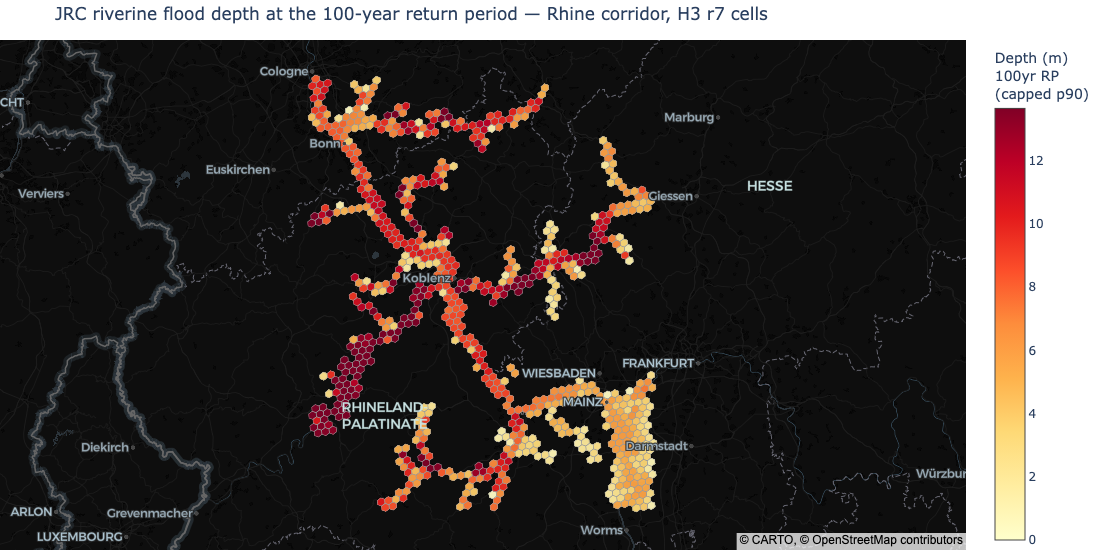

In [8]:
MAP_STYLE = "carto-darkmatter"  # dark basemap: low depths stay legible, unlike on a light one
MAP_VIEW = dict(map_zoom=7.3, map_center={"lat": 50.3, "lon": 7.75})

hex_geojson = {
    "type": "FeatureCollection",
    "features": [
        {"type": "Feature", "id": str(cell), "geometry": mapping(cell_polygon(cell))}
        for cell in risk["cell_index"]
    ],
}

# A handful of extreme (possibly artifact) cells would otherwise stretch the
# scale so far that the other 90% of (still meaningful) depths all read as
# the same pale color.
depth_cap = risk["depth_m"].quantile(0.90)

fig_hex = go.Figure(
    go.Choroplethmap(
        geojson=hex_geojson,
        locations=risk["cell_index"].astype(str),
        z=risk["depth_m"],
        zmin=0,
        zmax=depth_cap,
        customdata=risk[["province", "place_count"]],
        hovertemplate=(
            "Province: %{customdata[0]}<br>Depth: %{z:.2f} m"
            "<br>Places: %{customdata[1]}<extra></extra>"
        ),
        colorscale="YlOrRd",
        marker_line_width=0.5,
        marker_line_color="#999999",
        marker_opacity=0.95,
        colorbar_title=f"Depth (m)<br>{RETURN_PERIOD_YEARS}yr RP<br>(capped p90)",
    )
)
fig_hex.update_layout(
    map_style=MAP_STYLE,
    **MAP_VIEW,
    margin=dict(l=0, r=0, t=40, b=0),
    title=(
        f"JRC riverine flood depth at the {RETURN_PERIOD_YEARS}-year return period "
        f"— Rhine corridor, H3 r{H3_RESOLUTION} cells"
    ),
)
fig_hex.show()


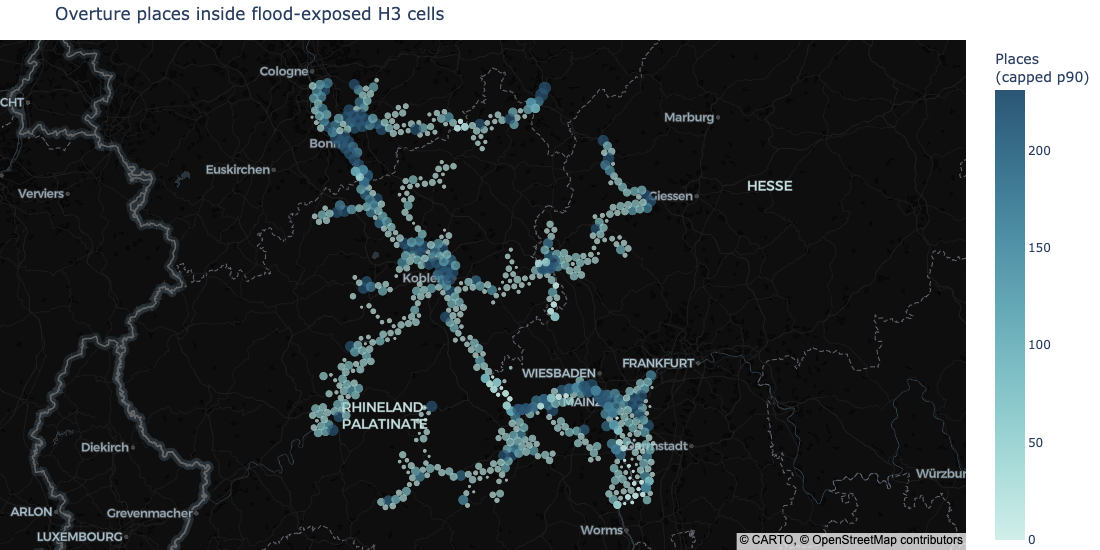

In [9]:
# A cool hue (vs. the hazard map's warm YlOrRd) keeps the two magnitudes visually
# distinct; a co-located overlay on the hex map would just bury the tiny hex
# fills under bubbles at this zoom, so impacted places get their own map.
impacted_cells = risk[risk["place_count"] > 0]
centroids = [cell_polygon(cell).centroid for cell in impacted_cells["cell_index"]]

# Place counts are just as right-skewed as depth (a few dense city cells vs.
# many sparse ones), so cap the color scale the same way.
place_cap = impacted_cells["place_count"].quantile(0.90)

fig_places = go.Figure(
    go.Scattermap(
        lat=[point.y for point in centroids],
        lon=[point.x for point in centroids],
        mode="markers",
        marker=dict(
            size=3 + np.log1p(impacted_cells["place_count"]) * 1.6,
            color=impacted_cells["place_count"],
            cmin=0,
            cmax=place_cap,
            colorscale="Teal",
            showscale=True,
            colorbar_title="Places<br>(capped p90)",
        ),
        customdata=impacted_cells[["province", "place_count"]],
        hovertemplate=(
            "Province: %{customdata[0]}<br>Places: %{customdata[1]}<extra></extra>"
        ),
    )
)
fig_places.update_layout(
    map_style=MAP_STYLE,
    **MAP_VIEW,
    margin=dict(l=0, r=0, t=40, b=0),
    title="Overture places inside flood-exposed H3 cells",
)
fig_places.show()


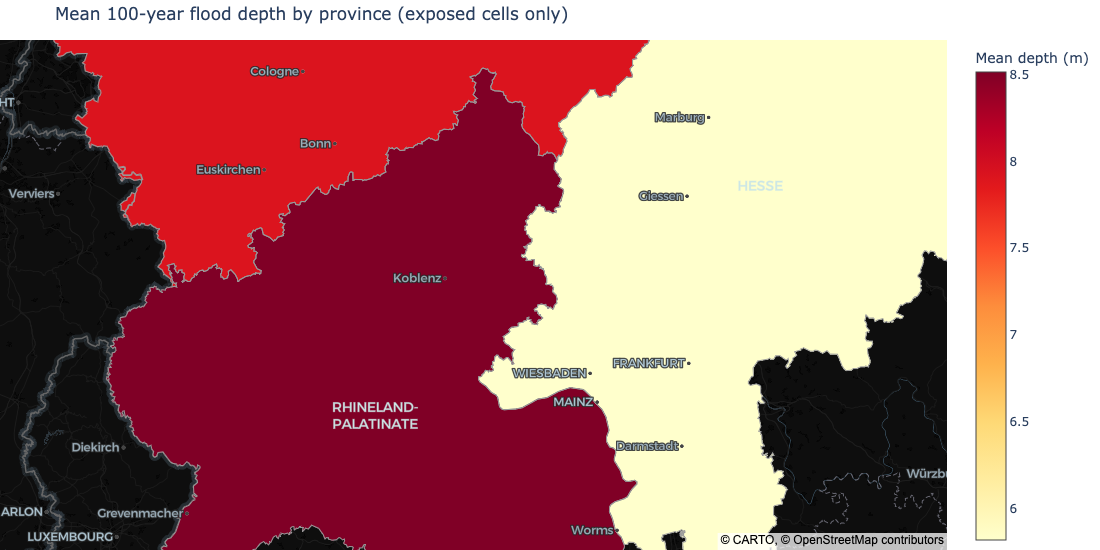

In [10]:
with open(ADM1_GEOJSON) as handle:
    adm1_geojson = json.load(handle)

fig_province = go.Figure(
    go.Choroplethmap(
        geojson=adm1_geojson,
        locations=province_risk["province"],
        z=province_risk["mean_depth_m"],
        featureidkey="properties.shapeName",
        customdata=province_risk[["impacted_places"]],
        colorscale="YlOrRd",
        marker_line_width=1,
        marker_line_color="#999999",
        colorbar_title="Mean depth (m)",
        hovertemplate=(
            "%{location}<br>Mean depth: %{z:.2f} m"
            "<br>Places: %{customdata[0]}<extra></extra>"
        ),
    )
)
fig_province.update_layout(
    map_style=MAP_STYLE,
    **MAP_VIEW,
    margin=dict(l=0, r=0, t=40, b=0),
    title=f"Mean {RETURN_PERIOD_YEARS}-year flood depth by province (exposed cells only)",
)
fig_province.show()


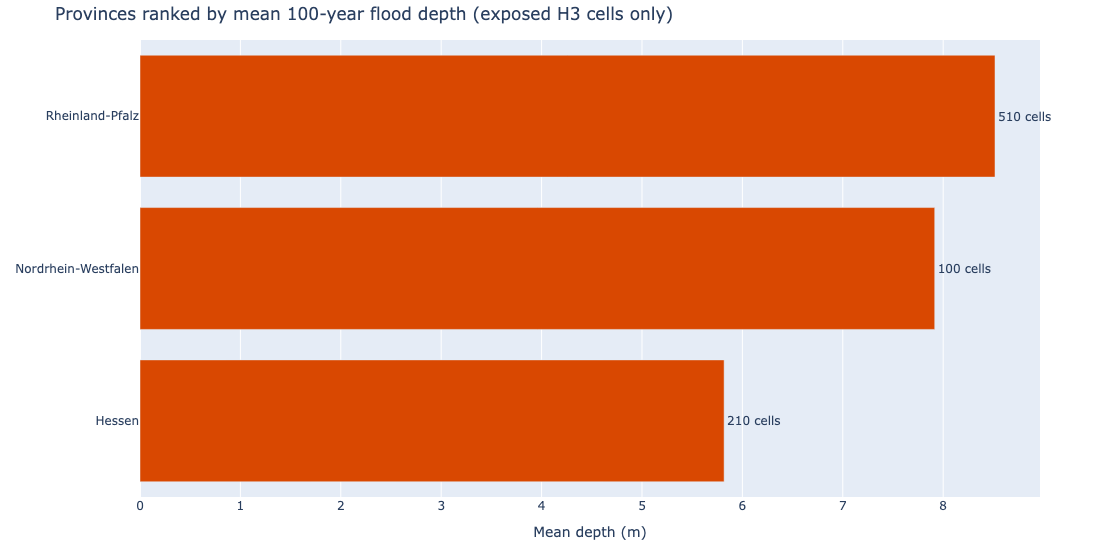

In [11]:
ranked = province_risk.sort_values("mean_depth_m")
fig_bar = go.Figure(
    go.Bar(
        x=ranked["mean_depth_m"],
        y=ranked["province"],
        orientation="h",
        marker_color="#D94801",
        text=ranked["exposed_cells"],
        texttemplate="%{text} cells",
        textposition="outside",
        cliponaxis=False,
        customdata=ranked[["impacted_places"]],
        hovertemplate=(
            "%{y}<br>Mean depth: %{x:.2f} m"
            "<br>Places: %{customdata[0]}<extra></extra>"
        ),
    )
)
fig_bar.update_layout(
    title=f"Provinces ranked by mean {RETURN_PERIOD_YEARS}-year flood depth (exposed H3 cells only)",
    xaxis_title="Mean depth (m)",
    margin=dict(l=140, r=60, t=40, b=40),
)
fig_bar.show()


## 6. Export a multi-layer PMTiles archive

The same three geometry layers this notebook already visualizes — H3 hex depths, Overture places, and province boundaries — export as one [PMTiles](https://protomaps.com/docs/pmtiles) archive via `crc_sdk.geometry.PMTilesBuild`: one streaming tiling pass, not three separate archives. Hex boundaries come from DuckDB's own `h3` extension (vectorized SQL, no Python per-cell loop); places keep their real point geometry this time instead of collapsing to a per-hex count.

**[⬇ Download risk_by_province.pmtiles](https://github.com/RiskThinking/crc-docs/blob/main/notebooks/artifacts/risk_by_province.pmtiles)** — small enough to commit directly (no Git LFS), so this link works straight from the repo without re-running the notebook. Drag it onto **[pmtiles.io](https://pmtiles.io)** (no server needed) to view it interactively. GitHub's notebook preview can't execute the JS a PMTiles viewer (MapLibre GL JS) needs, so this stays a downloadable artifact rather than an inline map — the same reason every map above renders as a static PNG fallback instead.


In [12]:
# Hex-depth layer: reuse the final risk rows, attach exact H3 boundary
# geometry only at the very end (narrow-key-first idiom).
con.register("risk_view", risk)
hex_layer_path = DATA_DIR / "hex_layer.parquet"
con.execute(
    f"""
    COPY (
        SELECT cell_index, province, depth_m, place_count,
               h3_cell_to_boundary_wkb(CAST(cell_index AS UBIGINT)) AS geometry
        FROM risk_view
    ) TO '{hex_layer_path}' (FORMAT PARQUET, COMPRESSION ZSTD)
    """
)

# Places layer: the same Overture query as Section 4, but keeping raw point
# geometry this time instead of collapsing to a per-hex count -- a "places"
# layer should be actual points, not one dot per flooded hex. Still
# restricted to the same flood-exposed cells Section 4 already joins
# against (not every place in the whole AOI bbox).
places_layer_path = DATA_DIR / "places_layer.parquet"
places_h3_geom_sql = indexer.build_h3_query(
    places_points_sql,
    H3_RESOLUTION,
    PolyfillMode.CENTROID,
    geom_col="geometry",
    h3_col="cell_index",
    preserve_geom=True,
)
con.execute(
    f"""
    COPY (
        SELECT p.name, p.confidence, p.geometry
        FROM ({places_h3_geom_sql}) p
        JOIN risk_cells r ON p.cell_index = r.cell_index
    ) TO '{places_layer_path}' (FORMAT PARQUET, COMPRESSION ZSTD)
    """
)

# Province-polygons layer: the same admin GeoJSON Section 2 already polyfilled,
# read via the same format adapter H3Indexer uses internally.
provinces_layer_path = DATA_DIR / "province_layer.parquet"
admin_relation = FormatAdapter.build_read_relation(
    con, str(ADM1_GEOJSON), GeoFormat.GEOJSON, geometry_column="geometry",
    preserve_source_geom=False,
)
con.execute(
    f"""
    COPY (SELECT * FROM {admin_relation})
    TO '{provinces_layer_path}' (FORMAT PARQUET, COMPRESSION ZSTD)
    """
)

# Layer intermediates stay under the gitignored DATA_DIR (scratch); the
# final archive goes to ARTIFACTS_DIR instead -- unlike DATA_DIR, this one
# is deliberately *not* gitignored, so the archive built below is small
# enough to commit directly (no Git LFS) and downloadable straight from
# the repo, not just reproducible by re-running the notebook.
ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)
PMTILES_PATH = ARTIFACTS_DIR / "risk_by_province.pmtiles"
result = (
    PMTilesBuild(con=con)
    .layer(str(hex_layer_path), name="hex_depth", zooms=(0, 12), preset=AREAS)
    .add_layer(str(places_layer_path), name="places", zooms=(0, 14), preset=POINTS)
    .add_layer(str(provinces_layer_path), name="provinces", zooms=(0, 10), preset=POLYGONS)
    .write(str(PMTILES_PATH))
)
print(
    f"wrote {result.output} "
    f"({PMTILES_PATH.stat().st_size / 1024 / 1024:.1f} MiB, layers={result.layers})"
)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

wrote artifacts/risk_by_province.pmtiles (20.9 MiB, layers=('hex_depth', 'places', 'provinces'))


## Scaling this up

[`pipelines/flood_admin_pipeline.py`](https://github.com/RiskThinking/crc-docs/blob/main/pipelines/flood_admin_pipeline.py) is this notebook's headless twin — the same EFAS area selection → AOI cache → canonical fit → curve evaluation → admin join → places → PMTiles flow. Widen `--bounds` to scale the run, choose `--cache-mode offline` after prefetching, and pass `--skip-pmtiles` on a machine without `tippecanoe`.